In [19]:
#Guilherme Moll, Pedro, Sergio
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch import nn
import os
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import kagglehub

In [20]:
# python
import os
import json
from pathlib import Path

kaggle_dir = Path(r'C:\Users\riley\PycharmProjects\processamento_imagems\.kaggle')
kaggle_file = kaggle_dir / "kaggle.json"

try:
    with kaggle_file.open("r", encoding="utf-8") as f:
        creds = json.load(f)
    os.environ["KAGGLE_USERNAME"] = creds.get("username", "")
    os.environ["KAGGLE_KEY"] = creds.get("key", "")
    if os.environ["KAGGLE_USERNAME"] and os.environ["KAGGLE_KEY"]:
        print("Kaggle credentials set from", str(kaggle_file))
    else:
        print("Credentials file found but missing `username` or `key` in", str(kaggle_file))
except FileNotFoundError:
    print("Kaggle credentials file not found at", str(kaggle_file))
except json.JSONDecodeError:
    print("Malformed JSON in", str(kaggle_file))
except Exception as e:
    print("Failed to load Kaggle credentials:", e)


Kaggle credentials set from C:\Users\riley\PycharmProjects\processamento_imagems\.kaggle\kaggle.json


In [21]:
import os
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset

VALID_EXTENSIONS = ('.jpg', '.jpeg', '.png', '.bmp')

class RiverDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform

        self.images = [f for f in os.listdir(image_dir) if f.lower().endswith(VALID_EXTENSIONS)]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.image_dir, img_name)
        base_name, _ = os.path.splitext(img_name)
        mask_name = base_name + ".png"
        mask_path = os.path.join(self.mask_dir, mask_name)

        image = cv2.imread(img_path)
        if image is None:
            raise FileNotFoundError(f"Image file not found or is unreadable at: {img_path}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if mask is None:
            raise FileNotFoundError(f"Mask file not found or is unreadable at: {mask_path}")

        _, mask = cv2.threshold(mask, 128, 255, cv2.THRESH_BINARY)
        mask = mask / 255.0
        mask = np.expand_dims(mask, axis=-1)

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']

        return image, mask

In [22]:
import segmentation_models_pytorch as smp

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
)

model.to(device)

Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

In [23]:
#transforms
IMG_MEAN = [0.485, 0.456, 0.406]
IMG_STD = [0.229, 0.224, 0.225]
IMG_HEIGHT, IMG_WIDTH = 256, 256

train_transform = A.Compose([
    A.Resize(height=IMG_HEIGHT, width=IMG_WIDTH),
    A.Rotate(limit=35, p=0.3),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.1),
    A.Normalize(mean=IMG_MEAN, std=IMG_STD, max_pixel_value=255.0),
    ToTensorV2(transpose_mask=True),
])

val_transform = A.Compose([
    A.Resize(height=IMG_HEIGHT, width=IMG_WIDTH),
    A.Normalize(mean=IMG_MEAN, std=IMG_STD, max_pixel_value=255.0),
    ToTensorV2(transpose_mask=True),
])

dataset_root = Path("river-water-segmentation-dataset") / "riwa_v2"
TRAIN_IMG_DIR = dataset_root / "images"
TRAIN_MASK_DIR = dataset_root / "masks"
VAL_IMG_DIR = dataset_root / "validation" / "images"
VAL_MASK_DIR = dataset_root / "validation" / "masks"

train_dataset = RiverDataset(
    image_dir=TRAIN_IMG_DIR,
    mask_dir=TRAIN_MASK_DIR,
    transform=train_transform
)

val_dataset = RiverDataset(
    image_dir=VAL_IMG_DIR,
    mask_dir=VAL_MASK_DIR,
    transform=val_transform
)

BATCH_SIZE = 8
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

images, masks = next(iter(train_loader))
print(f"Image batch shape: {images.shape}")
print(f"Mask batch shape: {masks.shape}")

images_val, masks_val = next(iter(val_loader))
print(f"Val Image batch shape: {images_val.shape}")
print(f"Val Mask batch shape: {masks_val.shape}")

Image batch shape: torch.Size([8, 3, 256, 256])
Mask batch shape: torch.Size([8, 1, 256, 256])
Val Image batch shape: torch.Size([8, 3, 256, 256])
Val Mask batch shape: torch.Size([8, 1, 256, 256])


In [24]:
# import torch.optim as optim
# import segmentation_models_pytorch as smp
# from tqdm import tqdm # For a nice progress bar
#
# # --- Parameters ---
# LEARNING_RATE = 1e-4
# NUM_EPOCHS = 30 # Start with 25, you can increase this if needed
# DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
#
# # --- Define Model ---
# model = smp.Unet(
#     encoder_name="resnet34",
#     encoder_weights="imagenet",
#     in_channels=3,
#     classes=1,
# )
# model.to(DEVICE)
#
# # --- Loss Function & Optimizer ---
# loss_fn = smp.losses.DiceLoss(mode='binary', from_logits=True)
# optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
# scaler = torch.cuda.amp.GradScaler() # For mixed precision (faster training)
#
# # --- Main Training & Validation Loop ---
# print("Starting training...")
# best_val_loss = float('inf') # Save the model with the best *validation* loss
#
# for epoch in range(NUM_EPOCHS):
#     print(f"\n--- Epoch {epoch+1}/{NUM_EPOCHS} ---")
#     # --- Training Phase ---
#     model.train()
#     train_loss = 0.0
#     train_loop = tqdm(train_loader, desc=f"Train Epoch {epoch+1}", leave=False)
#
#     for batch_idx, (data, targets) in enumerate(train_loop):
#         data = data.to(device=DEVICE)
#         targets = targets.to(device=DEVICE, dtype=torch.float32)
#
#         with torch.cuda.amp.autocast():
#             predictions = model(data)
#             loss = loss_fn(predictions, targets)
#
#         optimizer.zero_grad()
#         scaler.scale(loss).backward()
#         scaler.step(optimizer)
#         scaler.update()
#
#         train_loss += loss.item()
#         train_loop.set_postfix(loss=loss.item())
#
#     avg_train_loss = train_loss / len(train_loader)
#     print(f"Epoch {epoch+1} Avg Train Loss: {avg_train_loss:.4f}")
#
#     # --- Validation Phase ---
#     model.eval()
#     val_loss = 0.0
#     val_loop = tqdm(val_loader, desc=f"Valid Epoch {epoch+1}", leave=False)
#
#     with torch.no_grad():
#         for data, targets in val_loop:
#             data = data.to(device=DEVICE)
#             targets = targets.to(device=DEVICE, dtype=torch.float32)
#
#             with torch.cuda.amp.autocast():
#                 predictions = model(data)
#                 loss_val = loss_fn(predictions, targets)
#
#             val_loss += loss_val.item()
#             val_loop.set_postfix(val_loss=loss_val.item())
#
#     avg_val_loss = val_loss / len(val_loader)
#     print(f"Epoch {epoch+1} Avg Val Loss:   {avg_val_loss:.4f}")
#
#     if avg_val_loss < best_val_loss:
#         best_val_loss = avg_val_loss
#         torch.save(model.state_dict(), "best_model.pth")
#         print(f"Validation Loss improved! Saving new best_model.pth")
#
# print("finished training")

In [25]:
import cv2
import numpy as np
import albumentations as A

inference_transform = A.Compose([
    A.Resize(height=IMG_HEIGHT, width=IMG_WIDTH),
    A.Normalize(mean=IMG_MEAN, std=IMG_STD, max_pixel_value=255.0),
    ToTensorV2(),
])

def get_water_mask(image_path, model):
    image = cv2.imread(image_path)
    if image is None:
        raise FileNotFoundError(f"Could not find image at {image_path}")

    original_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    original_h, original_w = original_image.shape[:2]

    augmented = inference_transform(image=original_image)
    img_tensor = augmented["image"].unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        logits = model(img_tensor)
        pred_prob = torch.sigmoid(logits)[0, 0].cpu().numpy()

    pred_resized = cv2.resize(pred_prob, (original_w, original_h))
    binary_mask = (pred_resized < 0.5).astype(np.uint8)

    return original_image, binary_mask

def analyze_river_levels(benchmark_path, current_path, model, threshold_sensitivity=0.05):
    print(f"Processing Benchmark: {benchmark_path}...")
    img_ref, mask_ref = get_water_mask(benchmark_path, model)

    print(f"Processing Current: {current_path}...")
    img_cur, mask_cur = get_water_mask(current_path, model)


    if img_ref.shape[:2] != img_cur.shape[:2]:
        print(f"resizing image from  {img_cur.shape[:2]} to {img_ref.shape[:2]}")
        target_h, target_w = img_ref.shape[:2]
        img_cur = cv2.resize(img_cur, (target_w, target_h))
        mask_cur = cv2.resize(mask_cur, (target_w, target_h), interpolation=cv2.INTER_NEAREST)


    water_pixels_ref = float(np.sum(mask_ref))
    water_pixels_cur = float(np.sum(mask_cur))

    total_pixels = mask_ref.size
    coverage_ref = water_pixels_ref / total_pixels
    coverage_cur = water_pixels_cur / total_pixels

    if water_pixels_ref == 0:
        print("no water pixels detected")
        return

    pct_change = (water_pixels_cur - water_pixels_ref) / water_pixels_ref

    status = "NORMAL"

    if pct_change > threshold_sensitivity:
        status = "FLOOD WARNING"
    elif pct_change < -threshold_sensitivity:
        status = "DROUGHT WARNING"

    print("\n" + "="*40)
    print(f"RESULT: {status}")
    print(f"Water Coverage Change: {pct_change*100:.2f}%")
    print("="*40 + "\n")

    fig, ax = plt.subplots(1, 3, figsize=(18, 6))

    ax[0].imshow(img_ref)
    ax[0].imshow(mask_ref, cmap='Blues', alpha=0.4)
    ax[0].set_title(f"referencia: {coverage_ref*100:.1f}%")
    ax[0].axis('off')

    ax[1].imshow(img_cur)
    ax[1].imshow(mask_cur, cmap='Blues', alpha=0.4)
    ax[1].set_title(f"atual: {coverage_cur*100:.1f}%")
    ax[1].axis('off')

    diff_map = np.zeros((*mask_ref.shape, 3), dtype=np.uint8)


    ref_bool = mask_ref > 0
    cur_bool = mask_cur > 0

    diff_map[ref_bool & cur_bool] = [0, 255, 0]
    diff_map[~ref_bool & cur_bool] = [255, 0, 0]
    diff_map[ref_bool & ~cur_bool] = [255, 255, 0]

    ax[2].imshow(diff_map)
    ax[2].set_title(f"análise de mudança \n vermelho=cheia, amarelho=seca, verde=estável")
    ax[2].axis('off')

    plt.tight_layout()
    plt.show()

In [26]:
from pathlib import Path

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights=None,
    in_channels=3,
    classes=1,
)
model.load_state_dict(torch.load("best_model.pth"))
model.to(device)
print("Model loaded successfully.")

flood_folder = Path("imagens/flood")

#rio0 sendo a imagem do rio em seu estado natural
benchmark_file = str(flood_folder / "rio0.jpg")

if not os.path.exists(benchmark_file):
    all_images = sorted(flood_folder.glob("*"))
    test_images = [img for img in all_images if img.name != "rio0.jpg" and img.suffix.lower() in ['.png', '.jpg', '.jpeg']]

    print(f"\nFound {len(test_images)} test images in {flood_folder}")
    print(f"Test images: {[img.name for img in test_images]}")

    if len(test_images) == 0:
        print("No test images found in the flood folder!")
    else:
        for i, current_file in enumerate(test_images, start=1):
            print(f"\n{'='*60}")
            print(f"Testing image {i}/{len(test_images)}: {current_file.name}")
            print(f"{'='*60}")

            if os.path.exists(str(current_file)):
                analyze_river_levels(benchmark_file, str(current_file), model, threshold_sensitivity=0.05)
            else:
                print(f"File not found: {current_file}")

        print("\n" + "="*60)
        print("="*60)


Model loaded successfully.


Using rio0.jpg as the benchmark (reference) image for drought analysis

Found 4 test images in imagens\drought
Test images: ['drought1.png', 'drought2.png', 'drought3.png', 'drought4.png']

Testing image 1/4: drought1.png
Processing Benchmark: imagens\flood\rio0.jpg...
Processing Current: imagens\drought\drought1.png...
resizing image from  (1536, 2752) to (691, 1214)

RESULT: DROUGHT WARNING
Water Coverage Change: -99.30%



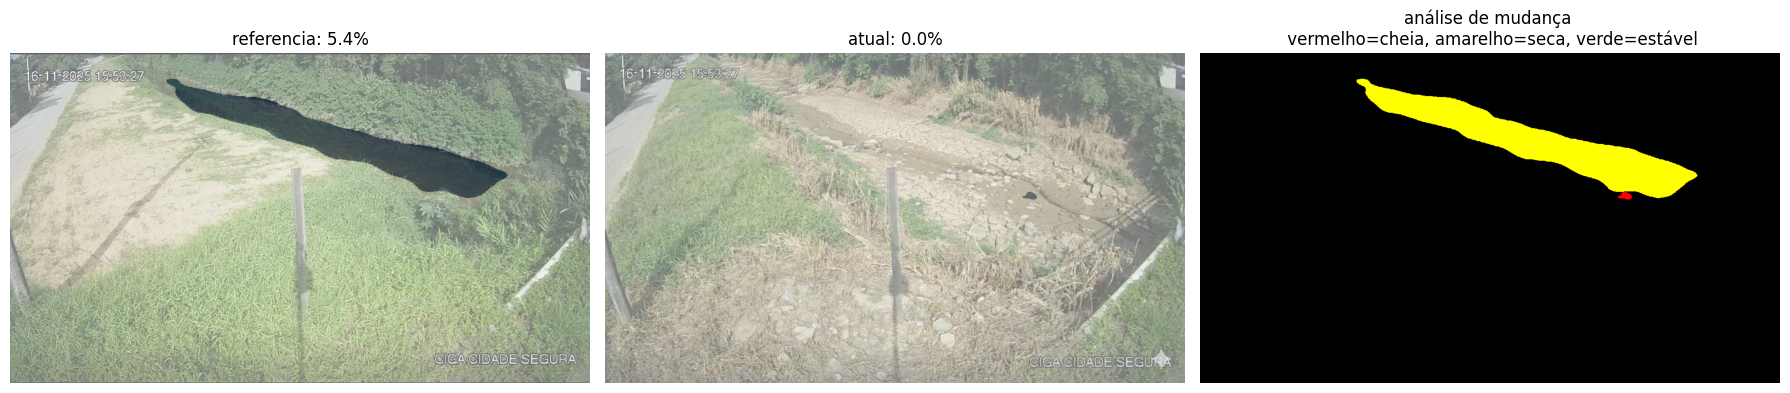


Testing image 2/4: drought2.png
Processing Benchmark: imagens\flood\rio0.jpg...
Processing Current: imagens\drought\drought2.png...
resizing image from  (1024, 1024) to (691, 1214)

RESULT: DROUGHT WARNING
Water Coverage Change: -100.00%



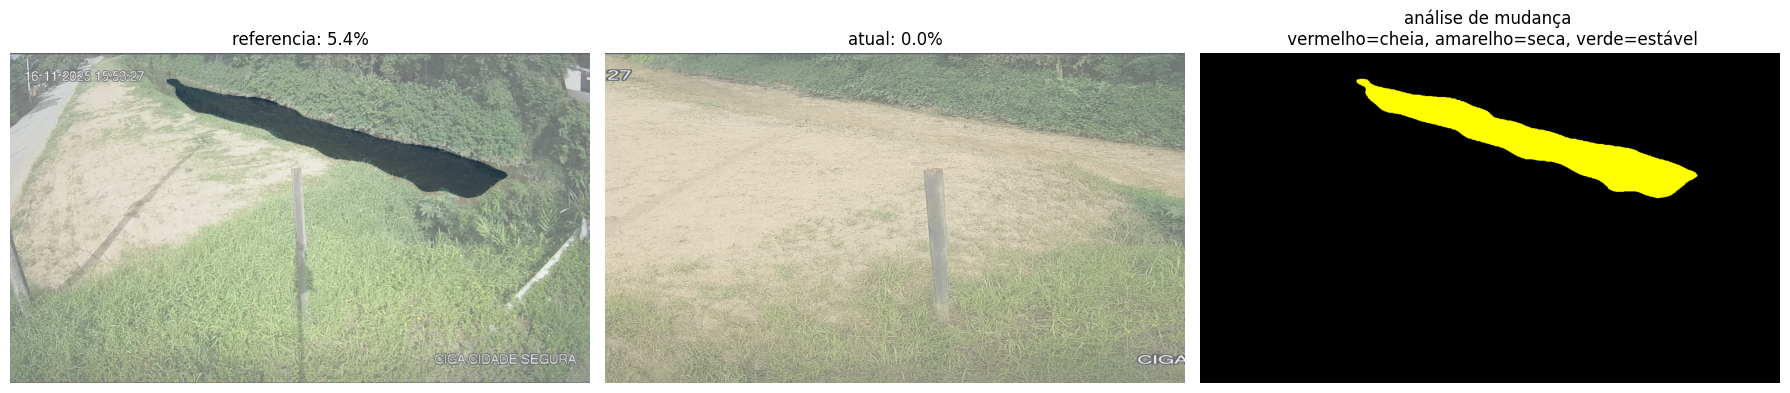


Testing image 3/4: drought3.png
Processing Benchmark: imagens\flood\rio0.jpg...
Processing Current: imagens\drought\drought3.png...
resizing image from  (768, 1344) to (691, 1214)

RESULT: DROUGHT WARNING
Water Coverage Change: -100.00%



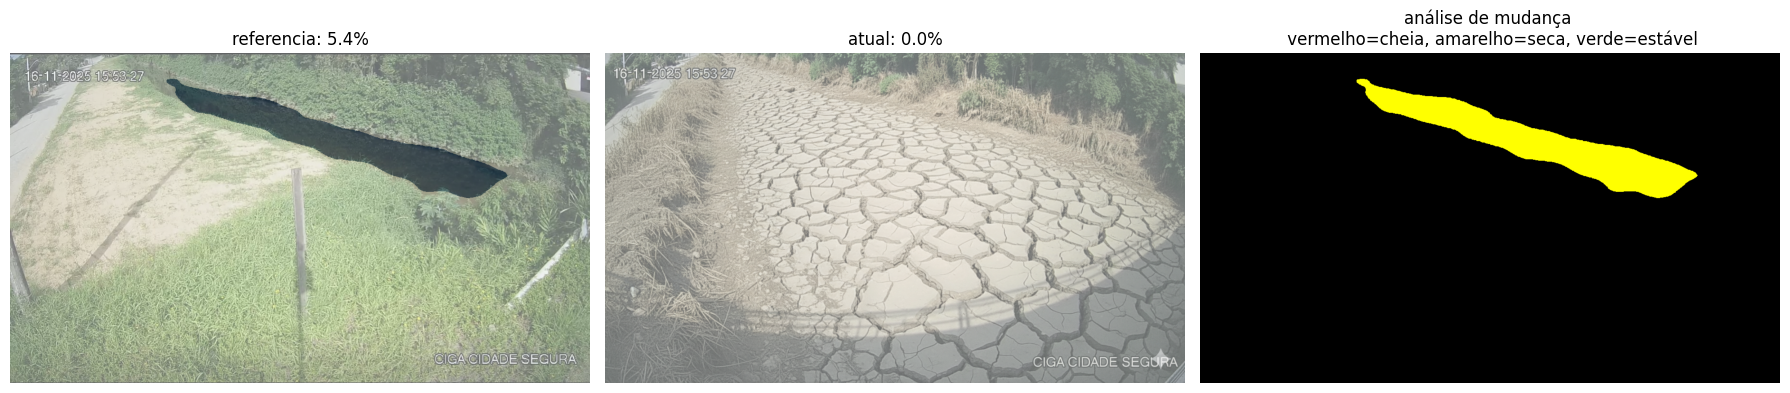


Testing image 4/4: drought4.png
Processing Benchmark: imagens\flood\rio0.jpg...
Processing Current: imagens\drought\drought4.png...
resizing image from  (1024, 1536) to (691, 1214)

RESULT: DROUGHT WARNING
Water Coverage Change: -100.00%



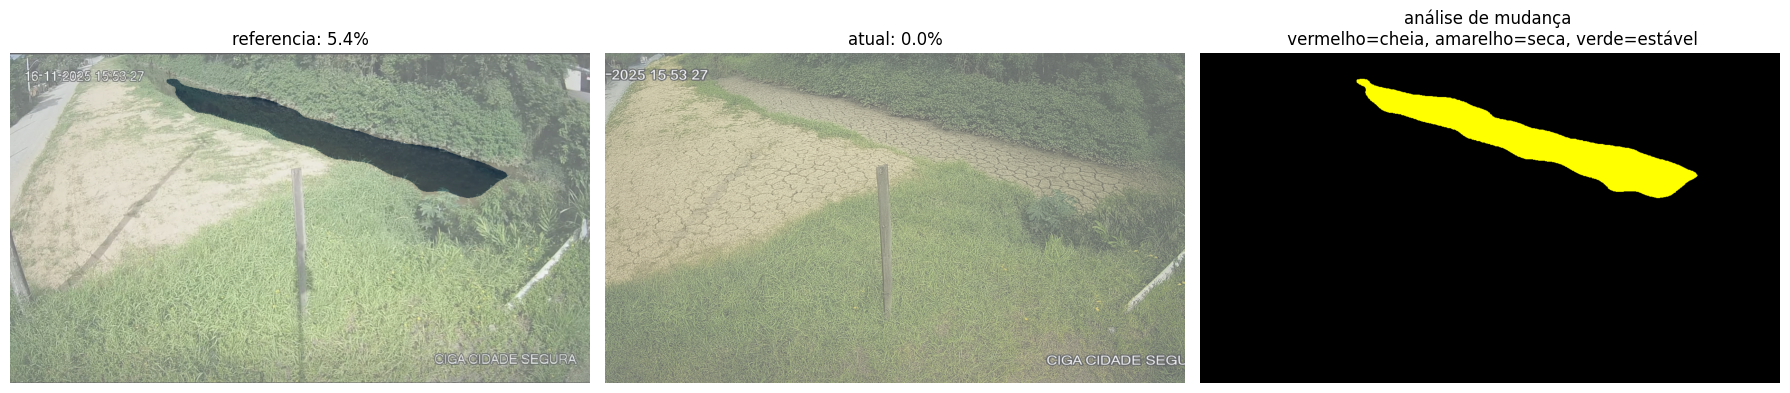


Drought analysis complete!


In [27]:
import matplotlib.pyplot as plt
from pathlib import Path

drought_folder = Path("imagens/drought")

benchmark_file = str(Path("imagens/flood") / "rio0.jpg")

if not os.path.exists(benchmark_file):
    print(f"Error: Benchmark image not found at {benchmark_file}")
else:
    print(f"Using rio0.jpg as the benchmark (reference) image for drought analysis")

    all_images = sorted(drought_folder.glob("*"))
    test_images = [img for img in all_images if img.suffix.lower() in ['.png', '.jpg', '.jpeg']]

    print(f"\nFound {len(test_images)} test images in {drought_folder}")
    print(f"Test images: {[img.name for img in test_images]}")

    if len(test_images) == 0:
        print("No test images found in the drought folder!")
    else:
        for i, current_file in enumerate(test_images, start=1):
            print(f"\n{'='*60}")
            print(f"Testing image {i}/{len(test_images)}: {current_file.name}")
            print(f"{'='*60}")

            if os.path.exists(str(current_file)):
                analyze_river_levels(benchmark_file, str(current_file), model, threshold_sensitivity=0.05)
            else:
                print(f"File not found: {current_file}")

        print("\n" + "="*60)
        print("Drought analysis complete!")
        print("="*60)
